# 1) Загрузка данных, первичный анализ, предобработка и разделение на train/test

На первом этапе мы загружаем датасет, анализируем его структуру, проверяем наличие пропусков, выполняем необходимую предобработку (удаление выбросов, кодирование категориальных признаков) и разделяем выборку на обучающую (70%) и тестовую (30%) с сохранением стратификации по целевому признаку.

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, export_graphviz, plot_tree
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="ticks")
%matplotlib inline

df = pd.read_csv('cardio_train.csv', sep=';')


print("Первичный анализ данных")

print(f"Размер датасета: {df.shape}")
print(f"\nПервые 5 строк:")
print(df.head())
print(f"\nСтолбцы: {df.columns.tolist()}")
print(f"\nИнформация о данных:")
print(df.info())

print(f"Пропуски:\n{df.isnull().sum()}")

print("Предобработка")


#удаляем столбец id
if 'id' in df.columns:
    df = df.drop('id', axis=1)
    print("Удалён столбец 'id'")

#удаление выбросов по артериальному давлению
initial_len = len(df)
df = df[(df['ap_hi'] >= 80) & (df['ap_hi'] <= 250)]
df = df[(df['ap_lo'] >= 50) & (df['ap_lo'] <= 180)]
print(f"Удалено выбросов по давлению: {initial_len - len(df)}")

#удаление выбросов по росту и весу
initial_len = len(df)
df = df[(df['height'] >= 100) & (df['height'] <= 250)]
df = df[(df['weight'] >= 30) & (df['weight'] <= 200)]
print(f"Удалено выбросов по росту/весу: {initial_len - len(df)}")

print(f"Размер датасета после очистки: {df.shape}")


#делим на обучающую и тестовую выборки
print("Разделение на TRAIN/TEST")

X = df.drop('cardio', axis=1)
y = df['cardio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")
print(f"\nРаспределение классов в обучающей выборке:\n{y_train.value_counts(normalize=True)}")
print(f"\nРаспределение классов в тестовой выборке:\n{y_test.value_counts(normalize=True)}")

#масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nМасштабирование выполнено (для логистической регрессии и SVM)")



Первичный анализ данных
Размер датасета: (70000, 13)

Первые 5 строк:
   id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0   0  18393       2     168    62.0    110     80            1     1      0   
1   1  20228       1     156    85.0    140     90            3     1      0   
2   2  18857       1     165    64.0    130     70            3     1      0   
3   3  17623       2     169    82.0    150    100            1     1      0   
4   4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  
0     0       1       0  
1     0       1       1  
2     0       0       1  
3     0       1       1  
4     0       0       0  

Столбцы: ['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Cou

# 2) Обучение моделей и оценка качества

На данном этапе мы обучаем три модели классификации: логистическую регрессию (линейная модель), SVM с радиальным базисным ядром (RBF) и дерево решений. Для оценки качества используем метрики accuracy (доля правильных ответов) и F1-score (среднее гармоническое между полнотой и точностью), а также полный отчёт классификации (classification_report). Для SVM и логистической регрессии используем масштабированные данные.

Обучение моделей и оценка качества
Логистическая регрессия
Accuracy: 0.7220
F1-score: 0.7010
AUC-ROC: 0.7864


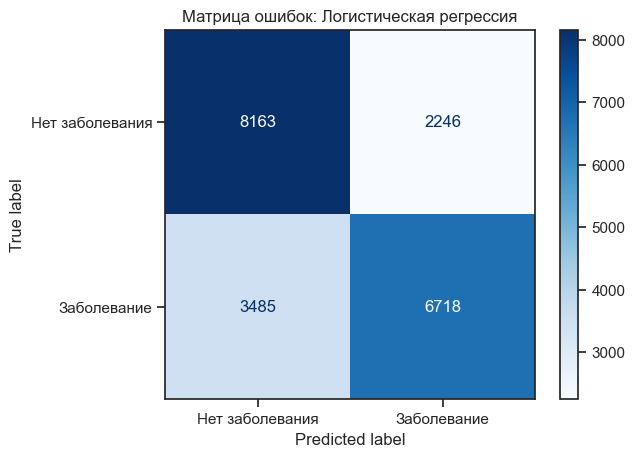

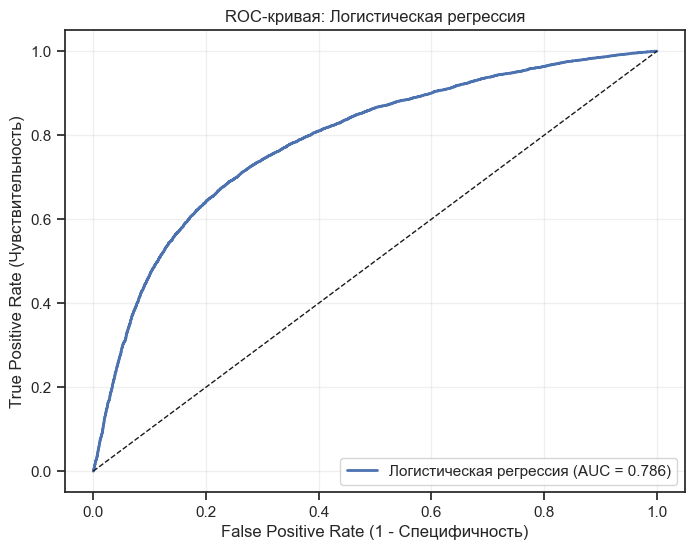

SVM (LinearSVC-линейное ядро)
Accuracy: 0.7210
F1-score: 0.6975
AUC-ROC: 0.7862


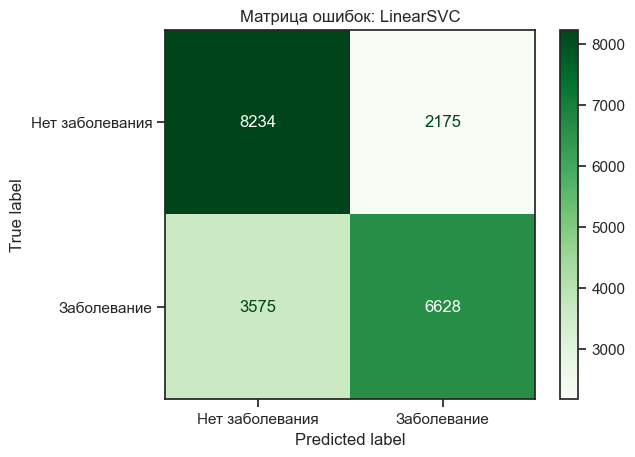

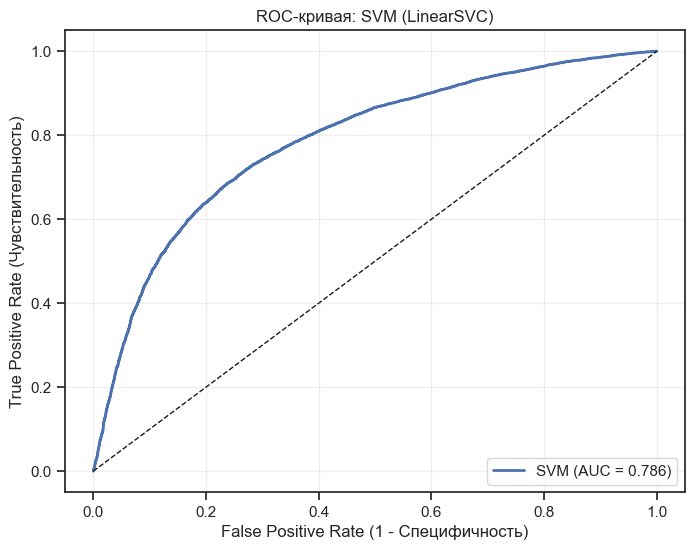

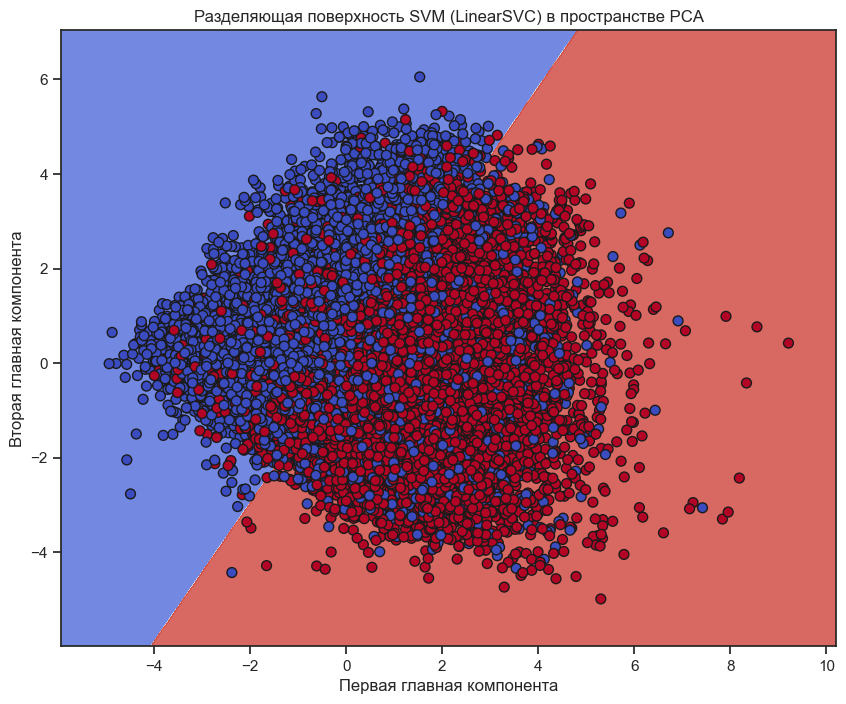

Дерево решений
Accuracy: 0.6353
F1-score: 0.6307
AUC-ROC: 0.6353


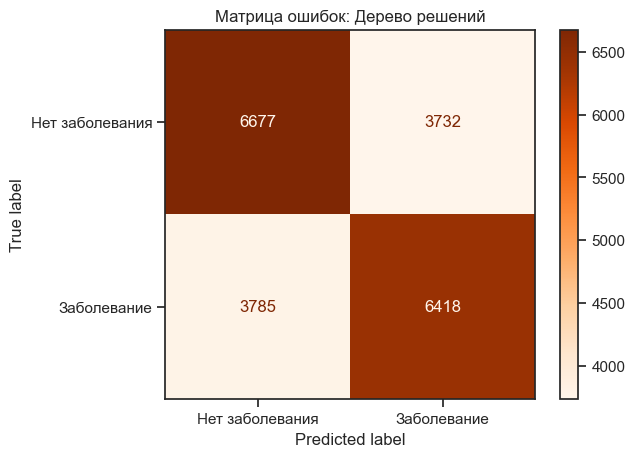

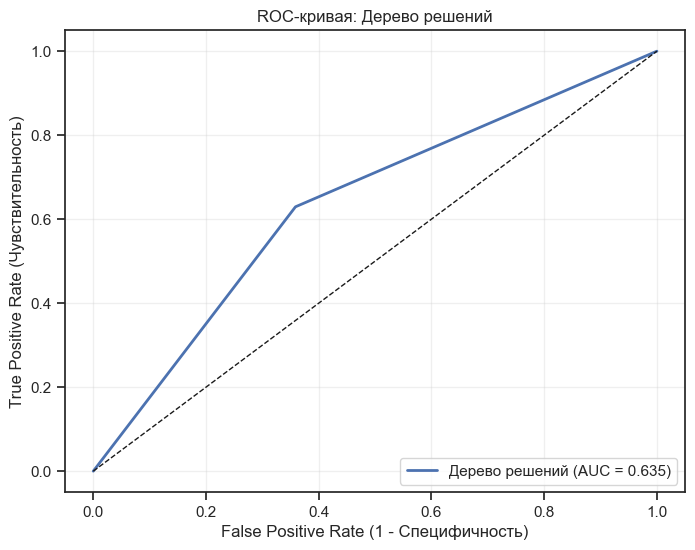

Сравнение качества моделей
                 Модель  Accuracy  F1-score  AUC-ROC
Логистическая регрессия  0.721958  0.700997 0.786371
              LinearSVC  0.721036  0.697464 0.786224
         Дерево решений  0.635310  0.630669 0.635333


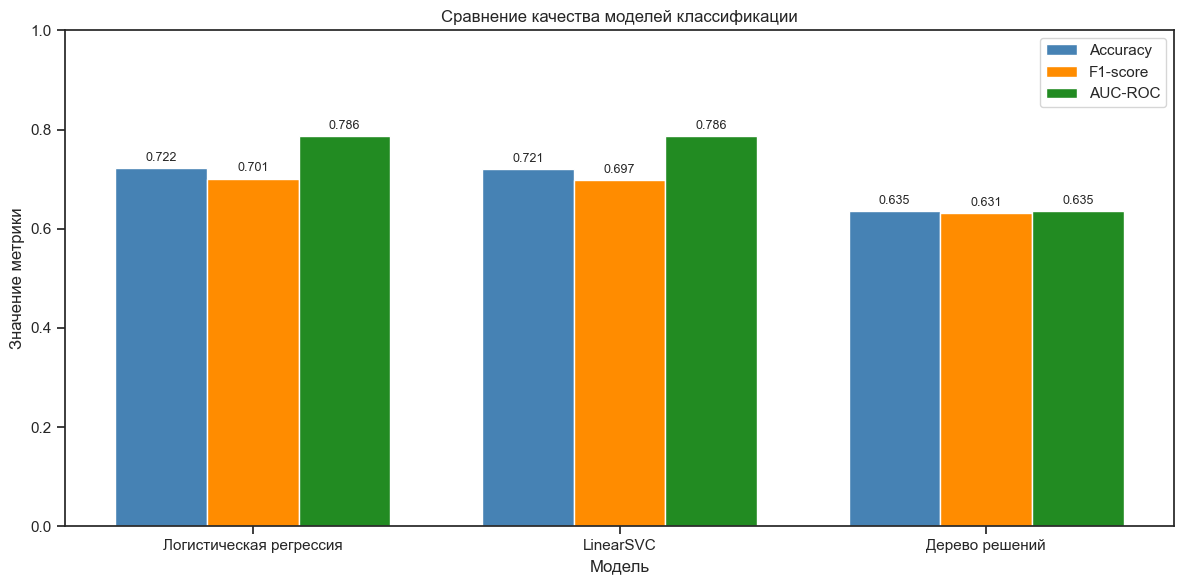

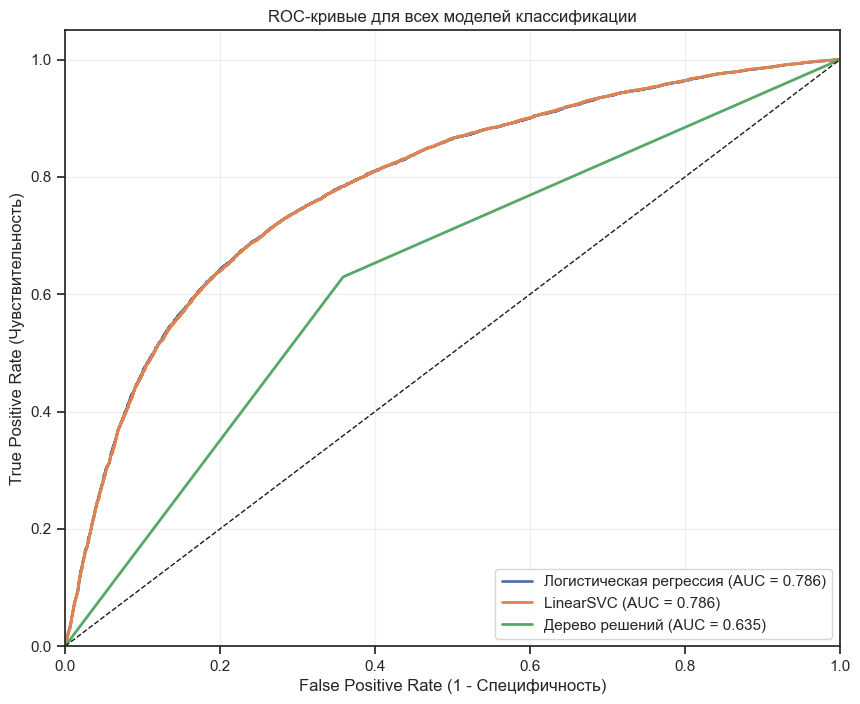


Вывод: Лучшая модель по F1-score — Логистическая регрессия


In [4]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
from sklearn.svm import LinearSVC
from sklearn.decomposition import PCA
#обучение и оценка качества
print("Обучение моделей и оценка качества")

#логистическая регрессия
print("Логистическая регрессия")


log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)
y_pred_log_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_log):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_log_proba):.4f}")

#матрица ошибок
cm_log = confusion_matrix(y_test, y_pred_log)
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=['Нет заболевания', 'Заболевание'])
disp_log.plot(cmap='Blues')
plt.title('Матрица ошибок: Логистическая регрессия')
plt.show()

#визуализация (ROC-кривая)
fpr_log, tpr_log, _ = roc_curve(y_test, y_pred_log_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label=f'Логистическая регрессия (AUC = {roc_auc_score(y_test, y_pred_log_proba):.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate (1 - Специфичность)')
plt.ylabel('True Positive Rate (Чувствительность)')
plt.title('ROC-кривая: Логистическая регрессия')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


#SVM (LinearSVC)
print("SVM (LinearSVC-линейное ядро)")

svm_model = LinearSVC(random_state=42, max_iter=5000, dual='auto')
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)
y_pred_svm_decision = svm_model.decision_function(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_svm):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_svm_decision):.4f}")

#матрица ошибок
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=['Нет заболевания', 'Заболевание'])
disp_svm.plot(cmap='Greens')
plt.title('Матрица ошибок: LinearSVC')
plt.show()

#ROC-кривая для svm
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_pred_svm_decision)
plt.figure(figsize=(8, 6))
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {roc_auc_score(y_test, y_pred_svm_decision):.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate (1 - Специфичность)')
plt.ylabel('True Positive Rate (Чувствительность)')
plt.title('ROC-кривая: SVM (LinearSVC)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

#визуализация svm разделяющая поверхность в пространстве двух главных компонент (PCA)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

svm_vis = LinearSVC(random_state=42, max_iter=5000, dual='auto')
svm_vis.fit(X_train_pca, y_train)

#сетка для отображения границы
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = svm_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.8, cmap='coolwarm')
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='coolwarm', edgecolors='k', s=50)
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.title('Разделяющая поверхность SVM (LinearSVC) в пространстве PCA')
plt.show()


#дерево решений
print("Дерево решений")


tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)
y_pred_tree_proba = tree_model.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_tree):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_tree):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_tree_proba):.4f}")

#матрица ошибок
cm_tree = confusion_matrix(y_test, y_pred_tree)
disp_tree = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=['Нет заболевания', 'Заболевание'])
disp_tree.plot(cmap='Oranges')
plt.title('Матрица ошибок: Дерево решений')
plt.show()

#roc кривая для дерева решений
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_pred_tree_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr_tree, tpr_tree, label=f'Дерево решений (AUC = {roc_auc_score(y_test, y_pred_tree_proba):.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate (1 - Специфичность)')
plt.ylabel('True Positive Rate (Чувствительность)')
plt.title('ROC-кривая: Дерево решений')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


#сравнение качества моделей
print("Сравнение качества моделей")
#таблица с результатами
results = pd.DataFrame({
    'Модель': ['Логистическая регрессия', 'LinearSVC', 'Дерево решений'],
    'Accuracy': [accuracy_score(y_test, y_pred_log),
                 accuracy_score(y_test, y_pred_svm),
                 accuracy_score(y_test, y_pred_tree)],
    'F1-score': [f1_score(y_test, y_pred_log),
                 f1_score(y_test, y_pred_svm),
                 f1_score(y_test, y_pred_tree)],
    'AUC-ROC': [roc_auc_score(y_test, y_pred_log_proba),
                roc_auc_score(y_test, y_pred_svm_decision),
                roc_auc_score(y_test, y_pred_tree_proba)]
})

print(results.to_string(index=False))

#гистограмма
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(results['Модель']))
width = 0.25

bars1 = ax.bar(x - width, results['Accuracy'], width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x, results['F1-score'], width, label='F1-score', color='darkorange')
bars3 = ax.bar(x + width, results['AUC-ROC'], width, label='AUC-ROC', color='forestgreen')

ax.set_xlabel('Модель')
ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение качества моделей классификации')
ax.set_xticks(x)
ax.set_xticklabels(results['Модель'])
ax.legend()
ax.set_ylim(0, 1)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

#совмещённые roc кривые всех моделей
plt.figure(figsize=(10, 8))
plt.plot(fpr_log, tpr_log, label=f'Логистическая регрессия (AUC = {roc_auc_score(y_test, y_pred_log_proba):.3f})', linewidth=2)
plt.plot(fpr_svm, tpr_svm, label=f'LinearSVC (AUC = {roc_auc_score(y_test, y_pred_svm_decision):.3f})', linewidth=2)
plt.plot(fpr_tree, tpr_tree, label=f'Дерево решений (AUC = {roc_auc_score(y_test, y_pred_tree_proba):.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Специфичность)')
plt.ylabel('True Positive Rate (Чувствительность)')
plt.title('ROC-кривые для всех моделей классификации')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print("\nВывод: Лучшая модель по F1-score — " + 
      results.loc[results['F1-score'].idxmax(), 'Модель'])

Для оценки качества моделей использовалась ROC-кривая и метрика AUC (площадь под кривой). ROC-кривая показывает зависимость доли верно классифицированных положительных объектов (True Positive Rate, Recall) от доли ложноположительных объектов (False Positive Rate) при изменении порога классификации.

Все три модели показывают хорошую разделяющую способность. Лучший результат показали логистическая регрессия и SVM. Это означает, что модели с высокой вероятностью присваивают более высокий риск заболевания реально больным пациентам по сравнению со здоровыми. 

На втором этапе лабораторной работы были обучены три модели классификации: логистическая регрессия, линейный метод опорных векторов (LinearSVC) и дерево решений. Для оценки качества использовались матрицы ошибок, метрики accuracy, F1-score и AUC-ROC. Логистическая регрессия показала accuracy 0.72, F1-score 0.7 и AUC-ROC 0.78. LinearSVC продемонстрировал практически аналогичные результаты: accuracy 0.72, F1-score 0.7, AUC-ROC 0.79. Дерево решений показало более низкие значения: accuracy 0.63, F1-score 0.63, AUC-ROC 0.64. Все три модели показали приемлемое качество, причем логистическая регрессия и SVM работают практически одинаково хорошо. Дерево решений уступает им по всем метрикам, что объясняется его склонностью к переобучению на данном объёме данных. По совокупности метрик лучшей моделью можно считать LinearSVC, показавший наибольшее значение AUC-ROC (0.79). Однако для практического использования в медицинской диагностике предпочтение следует отдавать логистической регрессии из-за её интерпретируемости и стабильности.

# 3) Важность признаков и визуализация дерева решений

Дерево решений позволяет оценить, какие признаки наиболее важны для классификации. Важность признака вычисляется как суммарное уменьшение неопределённости (Gini impurity) во всех узлах, где этот признак использовался. Для визуализации дерева используем библиотеки graphviz и pydotplus. Также выведем правила дерева в текстовом виде.

Важность признаков в дереве

Важность признаков (отсортировано по убыванию):
--------------------------------------------------
1. age: 0.3196
2. ap_hi: 0.2309
3. weight: 0.1596
4. height: 0.1466
5. ap_lo: 0.0393
6. cholesterol: 0.0331
7. gender: 0.0198
8. gluc: 0.0192
9. active: 0.0152
10. smoke: 0.0097
11. alco: 0.0072


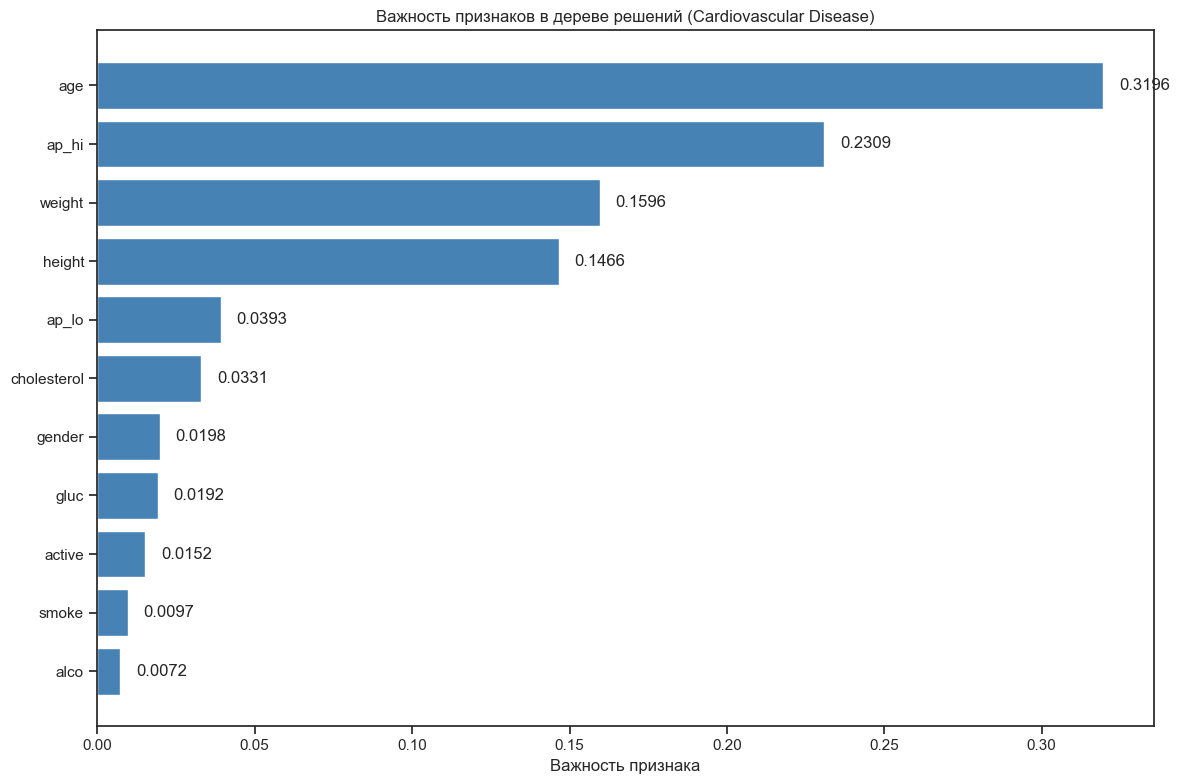

Визуализация дерева решений


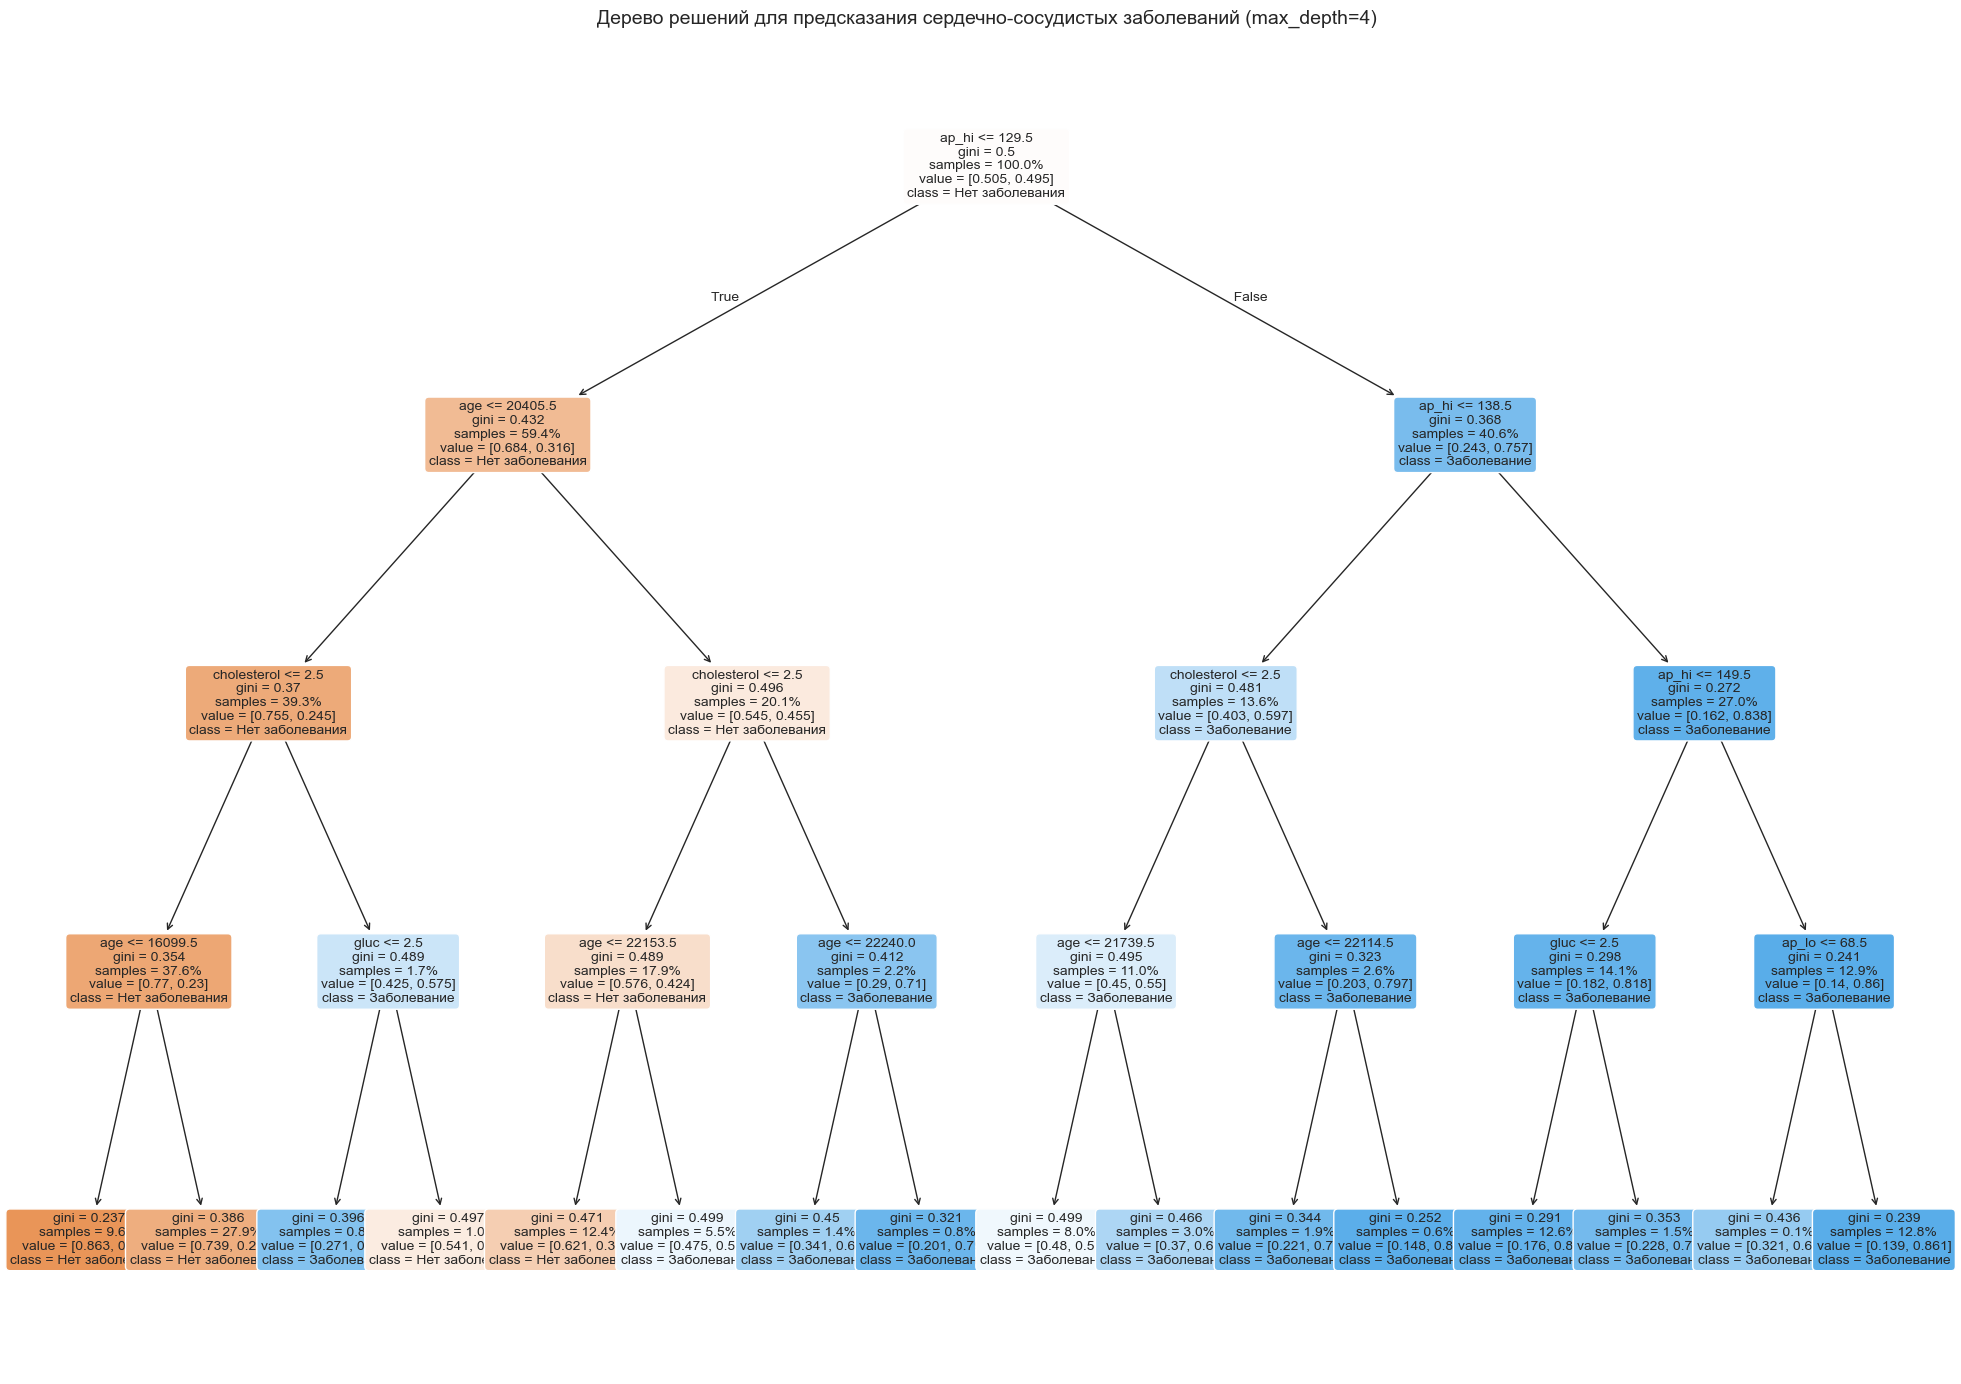

Правила дерева решений в текстовом виде

|--- ap_hi <= 129.50
|   |--- age <= 20405.50
|   |   |--- cholesterol <= 2.50
|   |   |   |--- age <= 16099.50
|   |   |   |   |--- class: 0
|   |   |   |--- age >  16099.50
|   |   |   |   |--- class: 0
|   |   |--- cholesterol >  2.50
|   |   |   |--- gluc <= 2.50
|   |   |   |   |--- class: 1
|   |   |   |--- gluc >  2.50
|   |   |   |   |--- class: 0
|   |--- age >  20405.50
|   |   |--- cholesterol <= 2.50
|   |   |   |--- age <= 22153.50
|   |   |   |   |--- class: 0
|   |   |   |--- age >  22153.50
|   |   |   |   |--- class: 1
|   |   |--- cholesterol >  2.50
|   |   |   |--- age <= 22240.00
|   |   |   |   |--- class: 1
|   |   |   |--- age >  22240.00
|   |   |   |   |--- class: 1
|--- ap_hi >  129.50
|   |--- ap_hi <= 138.50
|   |   |--- cholesterol <= 2.50
|   |   |   |--- age <= 21739.50
|   |   |   |   |--- class: 1
|   |   |   |--- age >  21739.50
|   |   |   |   |--- class: 1
|   |   |--- cholesterol >  2.50
|   |   |   |--- age

In [9]:

#важность признаков

print("Важность признаков в дереве")
#получаем важность признаков
feature_importance = tree_model.feature_importances_
feature_names = X_train.columns
#сортируем по убыванию
sorted_idx = np.argsort(feature_importance)[::-1]

print("\nВажность признаков (отсортировано по убыванию):")
print("-" * 50)
for i, idx in enumerate(sorted_idx):
    print(f"{i+1}. {feature_names[idx]}: {feature_importance[idx]:.4f}")

#график важности признаков (горизонтальные столбцы)
plt.figure(figsize=(12, 8))
bars = plt.barh(range(len(feature_importance)), feature_importance[sorted_idx], align='center', color='steelblue')
plt.yticks(range(len(feature_importance)), [feature_names[i] for i in sorted_idx])
plt.xlabel('Важность признака')
plt.title('Важность признаков в дереве решений (Cardiovascular Disease)')
plt.gca().invert_yaxis()

#добавляем значения на столбцы
for i, (bar, val) in enumerate(zip(bars, feature_importance[sorted_idx])):
    plt.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center')

plt.tight_layout()
plt.show()


#визуализация дерева решений (через matplotlib)

print("Визуализация дерева решений")
from sklearn.tree import plot_tree

#ограничим глубину дерева до 4 для наглядности 
tree_viz = DecisionTreeClassifier(random_state=42, max_depth=4)
tree_viz.fit(X_train, y_train)

plt.figure(figsize=(20, 14))
plot_tree(
    tree_viz,
    feature_names=feature_names,
    class_names=['Нет заболевания', 'Заболевание'],
    filled=True,
    rounded=True,
    fontsize=10,
    impurity=True,
    proportion=True
)
plt.title('Дерево решений для предсказания сердечно-сосудистых заболеваний (max_depth=4)', fontsize=14)
plt.tight_layout()
plt.show()


#правила дерева решений в текстовом виде 
print("Правила дерева решений в текстовом виде")
from sklearn.tree import export_text

tree_rules = export_text(tree_viz, feature_names=list(feature_names))
print("\n" + tree_rules)



На третьем этапе построены график важности признаков и визуализация дерева решений. Анализ показал, что наибольший вклад в классификацию вносят признаки age, ap_hi, weighr. Визуализация дерева с ограничением глубины 4 уровня позволила получить интерпретируемую структуру принятия решений, где корневым узлом является систолическое давление. Текстовые правила дерева делают модель полностью прозрачной для понимания. Таким образом, дерево решений, уступая логистической регрессии и SVM по метрикам качества, обладает важным преимуществом — интерпретируемостью результатов.

# Вывод

В ходе выполнения лабораторной работы был проведён анализ датасета Cardiovascular Disease Dataset для задачи классификации сердечно-сосудистых заболеваний. После предобработки данных (удаление выбросов, масштабирование признаков) и разделения выборки на обучающую и тестовую (70/30) были обучены три модели: логистическая регрессия, линейный метод опорных векторов (LinearSVC) и дерево решений.
Оценка качества показала, что логистическая регрессия и SVM демонстрируют практически одинаковые результаты. Дерево решений показало несколько более низкие значения. Наилучшей моделью по совокупности метрик является LinearSVC.
Анализ важности признаков в дереве решений выявил, что наиболее значимыми являются возраст, систолическое давление и вес. Признаки употребления алкоголя и пола показали нулевую важность. Визуализация дерева и текстовые правила сделали модель полностью интерпретируемой.
Таким образом, для практического использования рекомендуется логистическая регрессия или SVM как модели с лучшим качеством, однако дерево решений предпочтительно в задачах, где важна прозрачность и объяснимость прогнозов.